<a href="https://colab.research.google.com/github/avni-arora/Delhi-Inflation-Trends-through-CPI-data/blob/main/Data_Cleaning_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How has the Cost of Urban Living in Delhi changed since 2020?
## A CPI Based Inflation Analysis Project

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

df = pd.read_csv('/content/drive/MyDrive/DatasetGOI.csv',parse_dates=['Date'], date_format='%b-%y')
df.head(5)


,Date,State,Category,Rural,Urban,Combined,Status,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2020-01-01,Delhi,Food,153.2,144.3,145.0000,F,NaN,NaN,NaN
1,2020-02-01,Delhi,Food,151.6,140.8,141.7000,F,NaN,NaN,NaN
2,2020-03-01,ALL India,Food,148.2,150.1,148.9000,F,NaN,NaN,NaN
3,2020-04-01,ALL India,Food,152.8,156.1,154.0000,F,NaN,NaN,NaN
4,2020-05-01,ALL India,Food,151.4,154.8,152.7154,F,NaN,NaN,NaN


In [ ]:
df.tail(10)

,Date,State,Category,Rural,Urban,Combined,Status,Unnamed: 7,Unnamed: 8,Unnamed: 9
428,2025-07-01,Delhi,Overall,175.8,174.5,174.6,F,NaN,NaN,NaN
429,2025-08-01,Delhi,Overall,176.7,176.0,176.0,F,NaN,NaN,NaN
430,2025-09-01,Delhi,Overall,176.4,176.0,176.0,F,NaN,NaN,NaN
431,2025-10-01,Delhi,Overall,176.1,175.7,175.7,F,NaN,NaN,NaN
432,2025-11-01,Delhi,Overall,175.9,174.8,174.9,F,NaN,NaN,NaN
433,2025-12-01,Delhi,Overall,175.6,173.4,173.5,F,NaN,NaN,NaN
434,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
436,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
437,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Summary of the Dataset

This dataset contains monthly Consumer Price Index (CPI) observations for Delhi across multiple expenditure categories from 2020 to 2025. The data was obtained from the Ministry of Statistics and Programme Implementation (MoSPI), Government of India, through the official CPI portal.

The dataset is structured as a time-series dataset, where each row represents the CPI value for a particular category during a specific month and year. The CPI values are provided separately for rural, urban, and combined populations.

The dataset includes major expenditure groups such as:

*   Food and beverages
*   Housing
*   Fuel and light
*   Clothing and footwear
*   Miscellaneous
*   Overall

This project primarily focuses on urban CPI values in Delhi to study how the cost of living has evolved since 2020, particularly in the post-pandemic period.



###Column Descriptions
 - `Date`: Represents the month and year of the CPI observation.
 - `State`:Indicates the geographical region for which CPI data is recorded. In this project, the focus is on Delhi but ALL India data has been taken for COVID months of Apr-Jul 2020 for maintaining continuity in data.
 - `Category`: Represents the CPI category or expenditure group, such as Food, Housing, Fuel, Clothing, Miscellaneous, or Overall Index.
 - `Rural`: CPI index value corresponding to rural households.
- `Urban`: CPI index value corresponding to urban households.
- `Combined`: Combined CPI index incorporating both rural and urban populations. Represents overall inflation trends across population groups.

####Note:

The project primarily focuses on analysis through Urban CPI column.
Rural and Combined CPI columns have only been included for future analysis.



###Additional Information

#### What is CPI?
The Consumer Price Index (CPI) is an economic indicator used to measure the average change in prices paid by consumers for a basket of goods and services over time. It is one of the most widely used measures of inflation.


####How CPI relates to inflation?
The Consumer Price Index (CPI) is an economic indicator used to measure the average change in prices paid by consumers for a basket of goods and services over time. It is one of the most widely used measures of inflation.

####What is a Base Year?
CPI values are measured relative to a reference year known as the base year. In the base year, the CPI value is set equal to 100.

The CPI data used in this project follows Base Year: 2012 = 100

CPI = 100 indicates price levels equivalent to the average prices in 2012.
CPI = 150 indicates that prices are approximately 50% higher than the base year average.

Using a base year allows inflation to be measured consistently across time.

####Advantages of Using CPI for Inflation Analysis
- CPI provides standardized and government-verified data for tracking inflation trends over time.
- Category-wise CPI helps compare how different aspects of living costs change over time.

####Limitations of Using CPI for Inflation Analysis
- CPI measures relative price changes rather than actual market prices or individual expenses.
- CPI may not accurately represent inflation experiences across all income groups or informal settlements.


###Issues with the DataSet

1. Dirty Data
- CPI values were initially stored as text instead of numeric datatype. `validity`
- Unnecessary Unnamed columns were generated during Excel export/import `consistency`
- Date values required conversion into proper datetime format for time-series analysis `validity`
- Missing months were absent as rows instead of explicit NaN entries `completeness`
- Rural housing CPI values are unavailable for all years. `completeness`
- Delhi-specific CPI observations for Mar–Jul 2020 and Mar–Jul 2021 were missing across all categories. ALL India data was used to maintain consistency in data. `completeness`
- Status column was removed because all records contained the same value (Final) and provided no analytical significance `consistency`
-Combined CPI values in the Housing category were incorrectly represented as 0, despite housing data being available for urban observations. `accuracy`
- Category names such as Fuel and Light and Food and Beverages were standardized to shorter labels (Fuel, Food) for consistency and easier visualization. `consistency`

2. Messy Data
- Category-wise reports were available separately which needed to be combined in a single dataframe in Excel. `structure`
- Missing months needed to be explicitly reintroduced into the dataset for proper time-series continuity `structure`


In [ ]:
df = df.drop(df.columns[-4:], axis=1)
df = df.drop(df.index[-4:], axis=0)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      434 non-null    datetime64[ns]
 1   State     434 non-null    object        
 2   Category  434 non-null    object        
 3   Rural     429 non-null    float64       
 4   Urban     434 non-null    float64       
 5   Combined  434 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 20.5+ KB


In [ ]:
df.tail(10)

,Date,State,Category,Rural,Urban,Combined
424,2025-03-01,Delhi,Overall,174.2,171.8,171.9
425,2025-04-01,Delhi,Overall,174.2,172.1,172.2
426,2025-05-01,Delhi,Overall,174.3,172.3,172.4
427,2025-06-01,Delhi,Overall,174.7,171.5,171.7
428,2025-07-01,Delhi,Overall,175.8,174.5,174.6
429,2025-08-01,Delhi,Overall,176.7,176.0,176.0
430,2025-09-01,Delhi,Overall,176.4,176.0,176.0
431,2025-10-01,Delhi,Overall,176.1,175.7,175.7
432,2025-11-01,Delhi,Overall,175.9,174.8,174.9
433,2025-12-01,Delhi,Overall,175.6,173.4,173.5


In [ ]:
df.sample(5)

,Date,State,Category,Rural,Urban,Combined
349,2025-02-01,Delhi,Miscellanous,164.9,165.6,165.5
413,2024-04-01,Delhi,Overall,169.7,169.2,169.2
110,2023-03-01,Delhi,Clothing,171.8,162.6,163.3
76,2020-05-01,ALL India,Clothing,153.2,150.4,152.3
379,2021-06-01,Delhi,Overall,155.4,154.1,154.2


In [ ]:
df[df["State"] == "ALL India"][["Date", "State", "Category"]]
#All months and categories for which we used ALL India CPI instead of Delhi CPI


,Date,State,Category
2,2020-03-01,ALL India,Food
3,2020-04-01,ALL India,Food
4,2020-05-01,ALL India,Food
5,2020-06-01,ALL India,Food
6,2020-07-01,ALL India,Food
74,2020-03-01,ALL India,Clothing
75,2020-04-01,ALL India,Clothing
76,2020-05-01,ALL India,Clothing
77,2020-06-01,ALL India,Clothing
78,2020-07-01,ALL India,Clothing


In [ ]:
df.loc[df["Category"] == "Housing", "Combined"] = df["Urban"]
df[df["Category"] == "Housing"].sample(5)

,Date,State,Category,Rural,Urban,Combined
213,2025-10-01,Delhi,Housing,0.0,172.7,172.7
192,2024-01-01,Delhi,Housing,0.0,168.9,168.9
152,2020-09-01,Delhi,Housing,0.0,166.9,166.9
156,2021-01-01,Delhi,Housing,0.0,166.1,166.1
190,2023-11-01,Delhi,Housing,0.0,168.9,168.9


In [ ]:
urban_df = df[['Date', 'Category', 'Urban']].copy()
urban_df.head(20)

,Date,Category,Urban
0,2020-01-01,Food,144.3
1,2020-02-01,Food,140.8
2,2020-03-01,Food,150.1
3,2020-04-01,Food,156.1
4,2020-05-01,Food,154.8
5,2020-06-01,Food,157.0
6,2020-07-01,Food,159.9
7,2020-08-01,Food,152.6
8,2020-09-01,Food,154.3
9,2020-10-01,Food,154.7


In [ ]:
urban_df['Inflation_MoM'] = (
    urban_df.groupby('Category')['Urban']
    .pct_change() * 100
)
urban_df['Inflation_YoY'] = (urban_df.groupby('Category')['Urban'].pct_change(periods=12) * 100)

urban_df.head(20)

,Date,Category,Urban,Inflation_MoM,Inflation_YoY
0,2020-01-01,Food,144.3,NaN,NaN
1,2020-02-01,Food,140.8,-2.425502,NaN
2,2020-03-01,Food,150.1,6.605114,NaN
3,2020-04-01,Food,156.1,3.997335,NaN
4,2020-05-01,Food,154.8,-0.832799,NaN
5,2020-06-01,Food,157.0,1.421189,NaN
6,2020-07-01,Food,159.9,1.847134,NaN
7,2020-08-01,Food,152.6,-4.565353,NaN
8,2020-09-01,Food,154.3,1.114024,NaN
9,2020-10-01,Food,154.7,0.259235,NaN


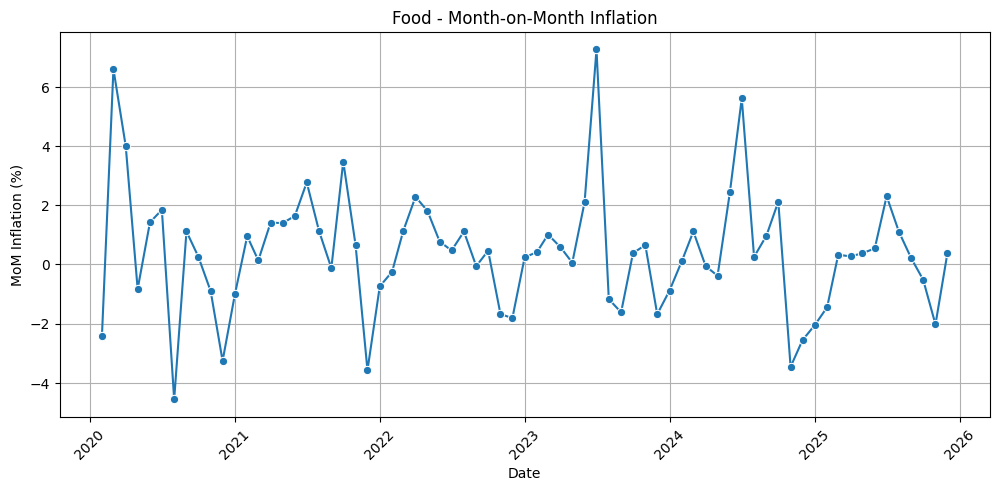

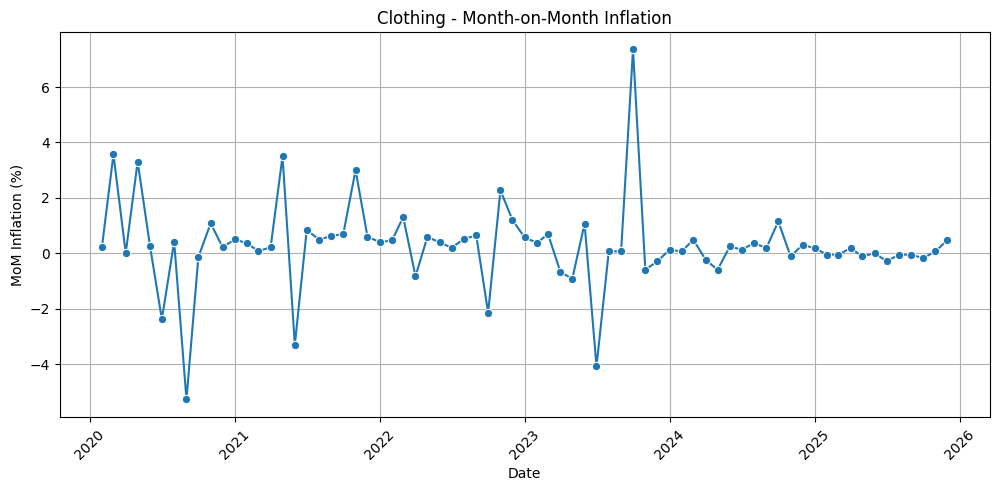

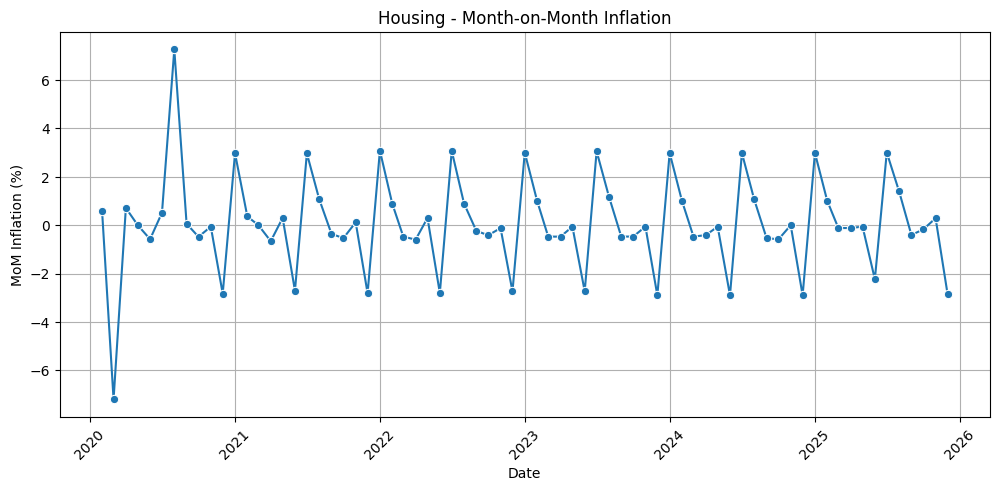

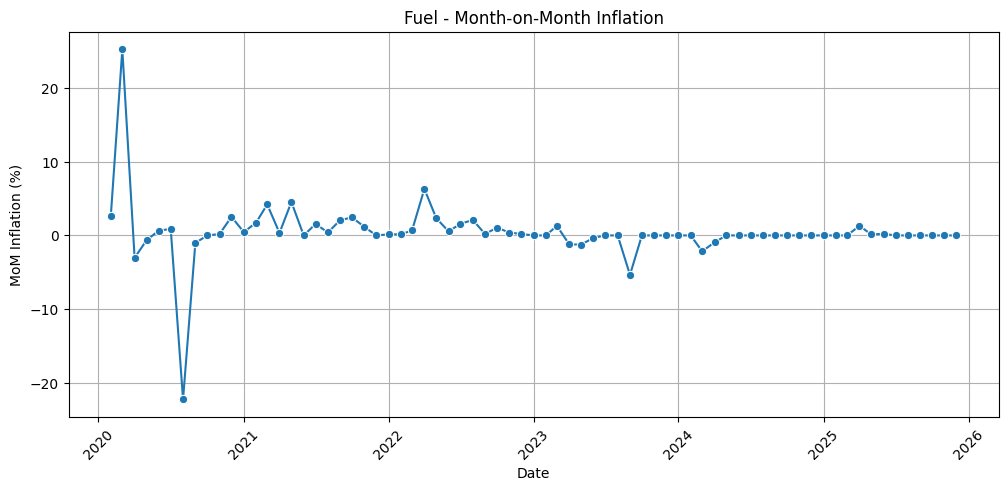

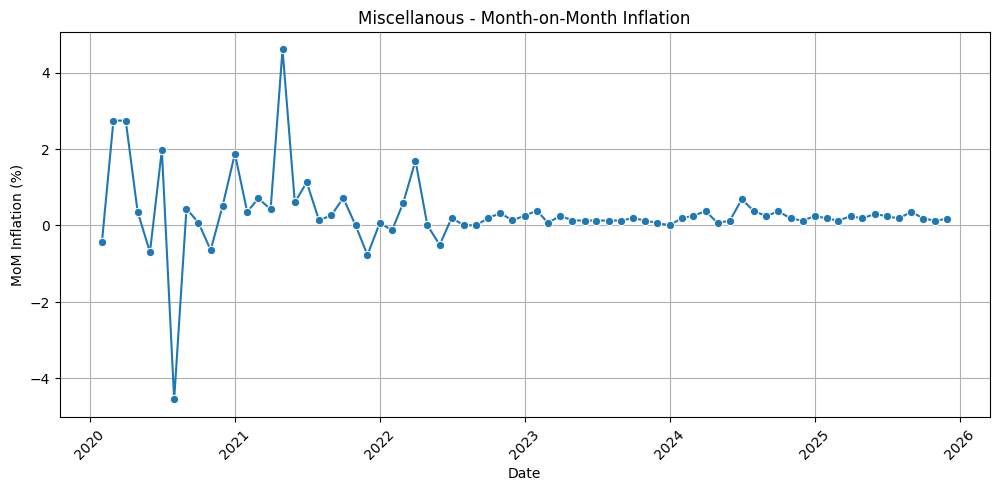

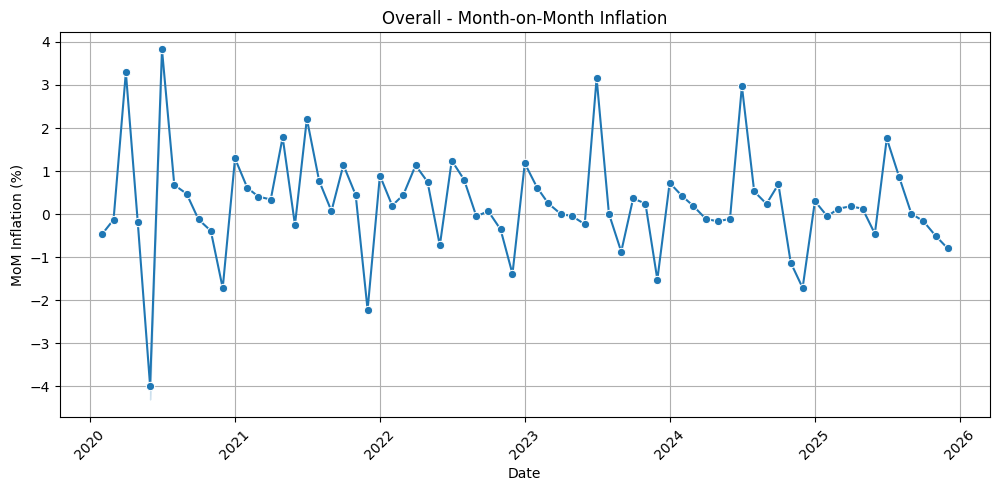

In [ ]:
categories = urban_df['Category'].unique()
for category in categories:
    temp_df = urban_df[urban_df['Category'] == category]
    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=temp_df,
        x='Date',
        y='Inflation_MoM',
        marker='o')

    plt.title(f'{category} - Month-on-Month Inflation')
    plt.xlabel('Date')
    plt.ylabel('MoM Inflation (%)')

    plt.xticks(rotation=45)
    plt.grid(True)

    plt.show()

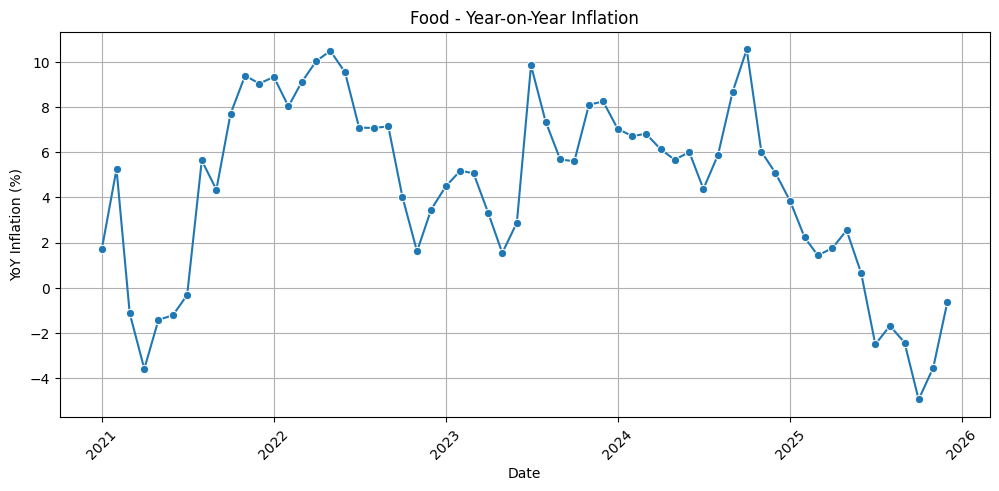

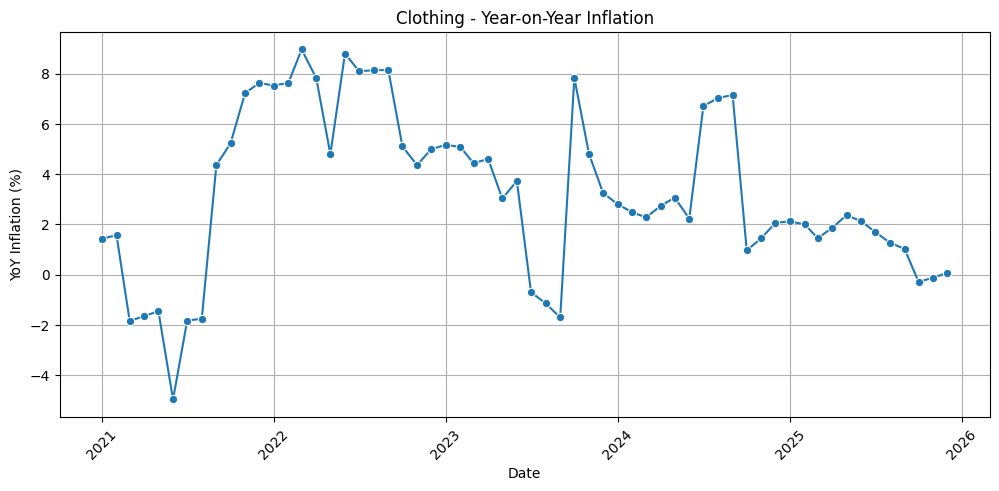

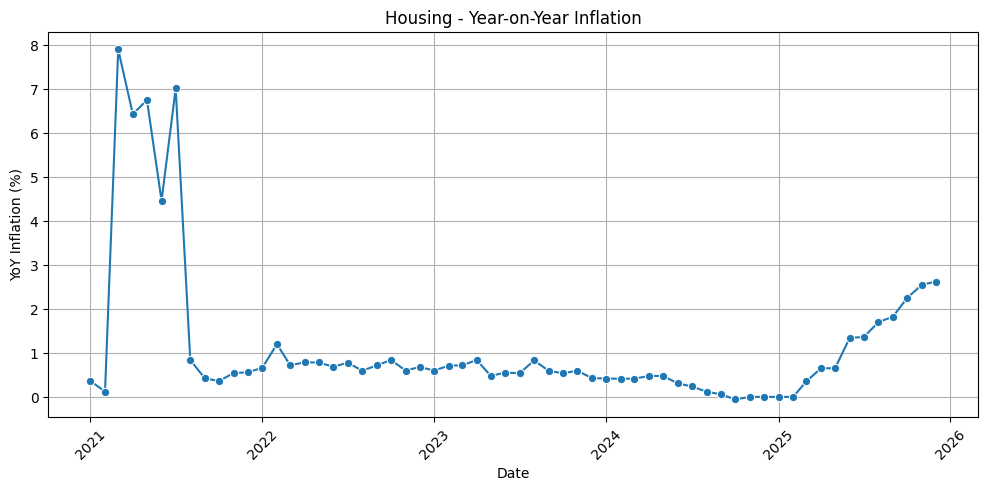

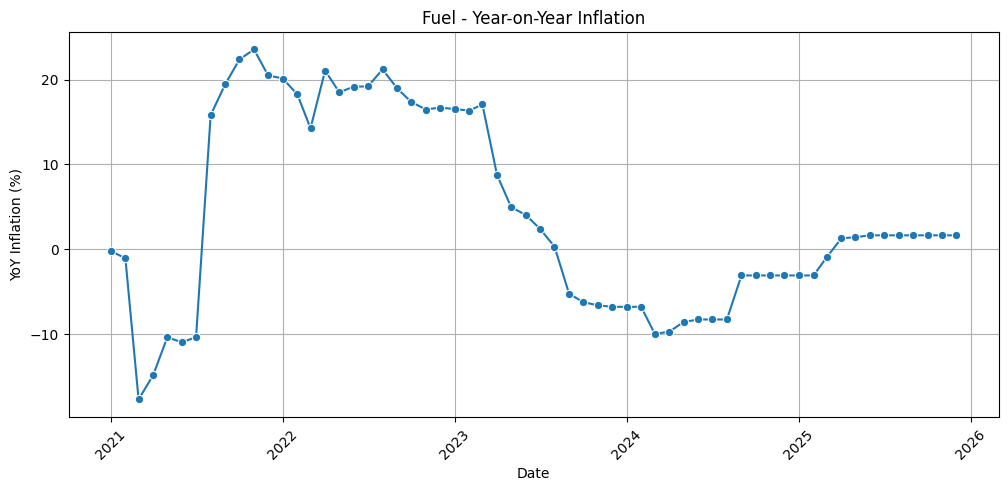

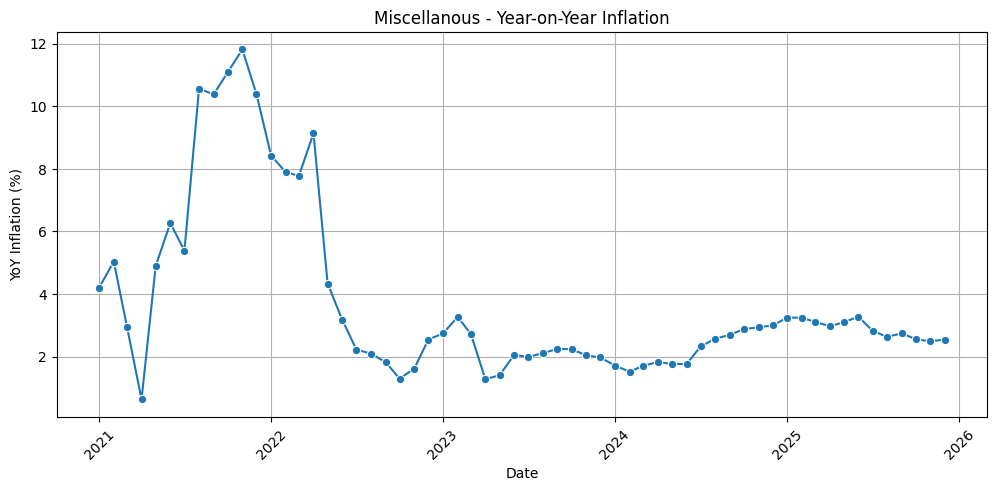

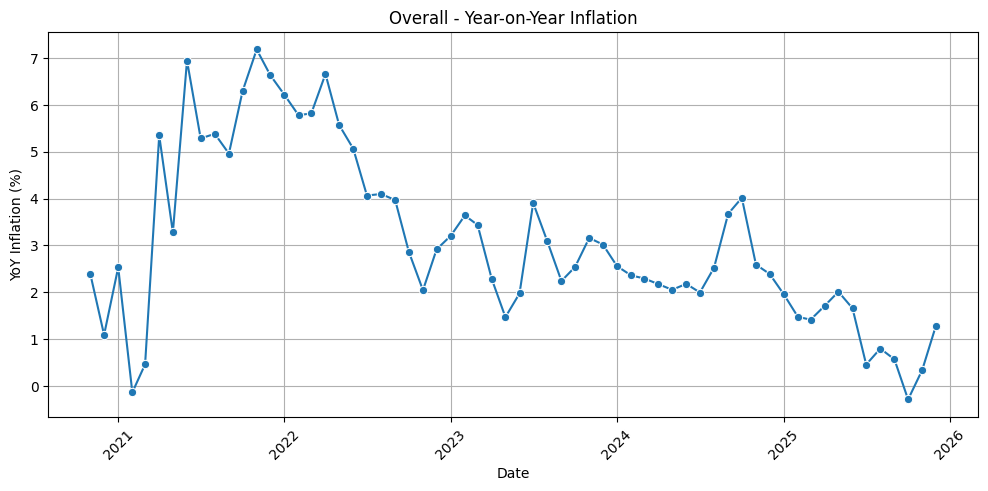

In [ ]:
# Loop through each category
for category in categories:

    temp_df = urban_df[urban_df['Category'] == category]

    plt.figure(figsize=(12, 5))

    sns.lineplot(
        data=temp_df,
        x='Date',
        y='Inflation_YoY',
        marker='o'
    )

    plt.title(f'{category} - Year-on-Year Inflation')
    plt.xlabel('Date')
    plt.ylabel('YoY Inflation (%)')

    plt.xticks(rotation=45)
    plt.grid(True)

    plt.show()

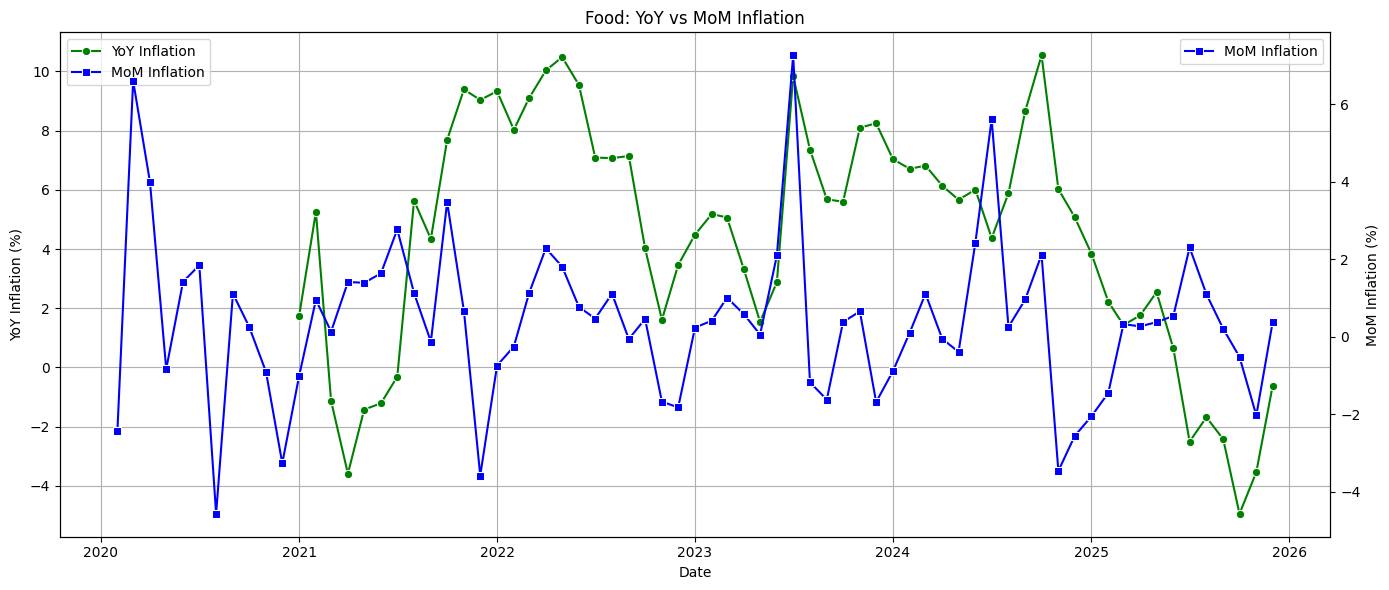

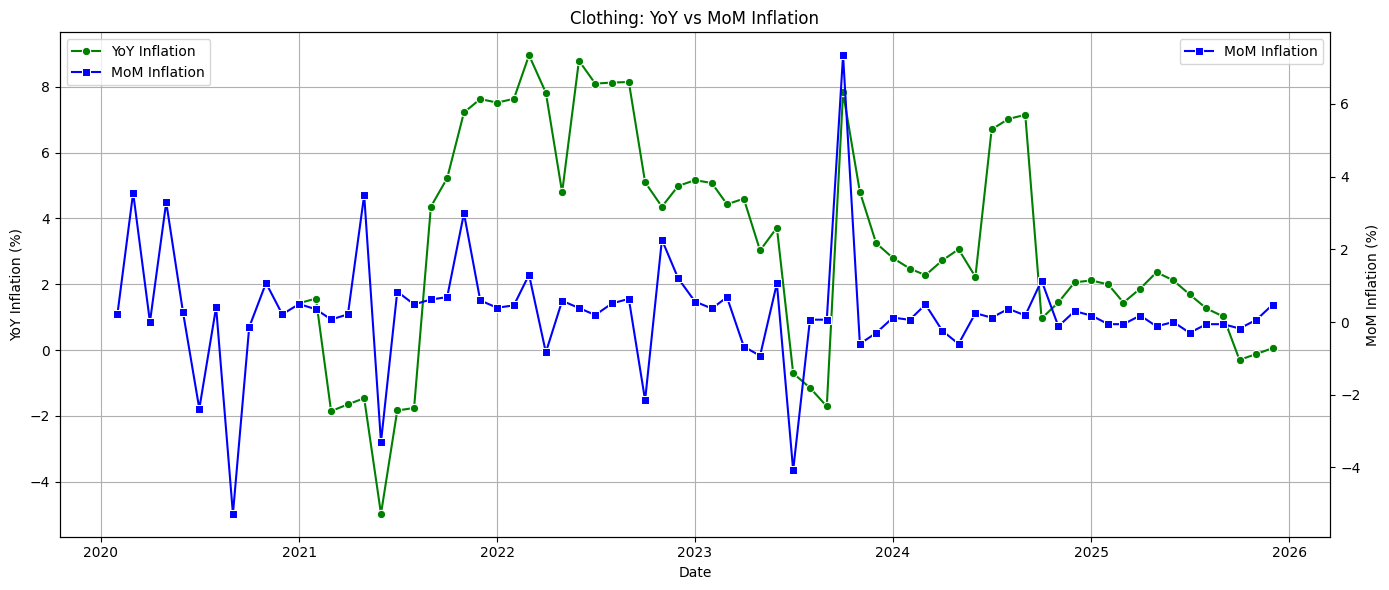

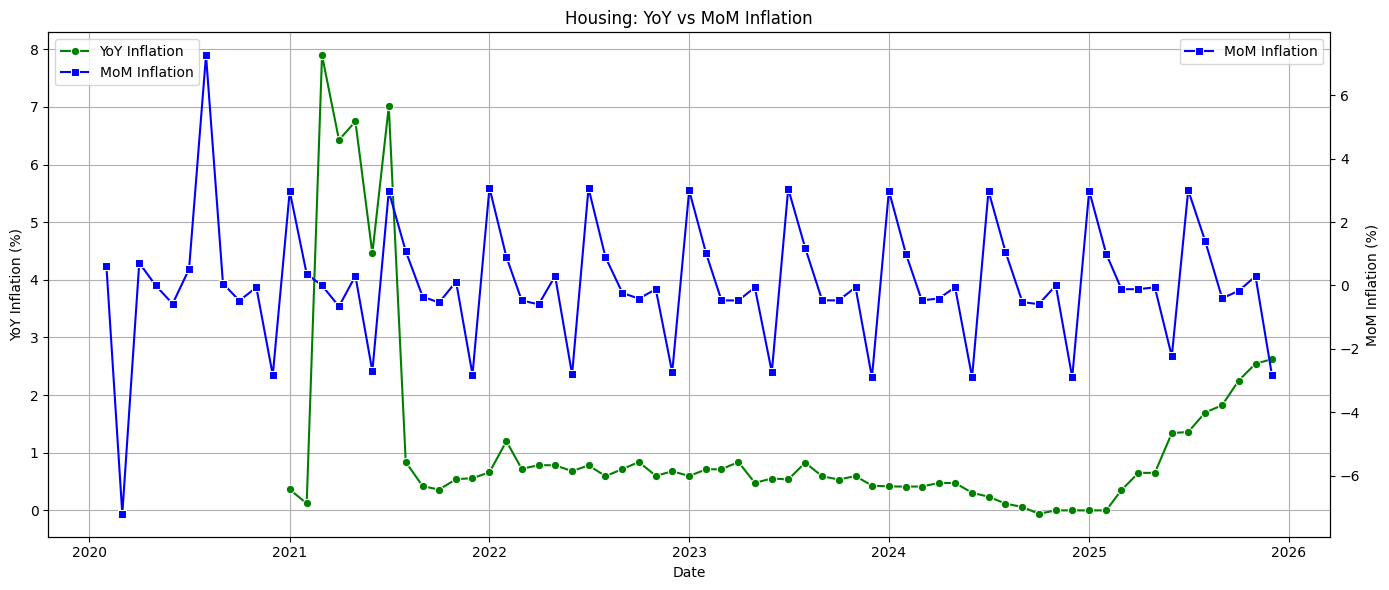

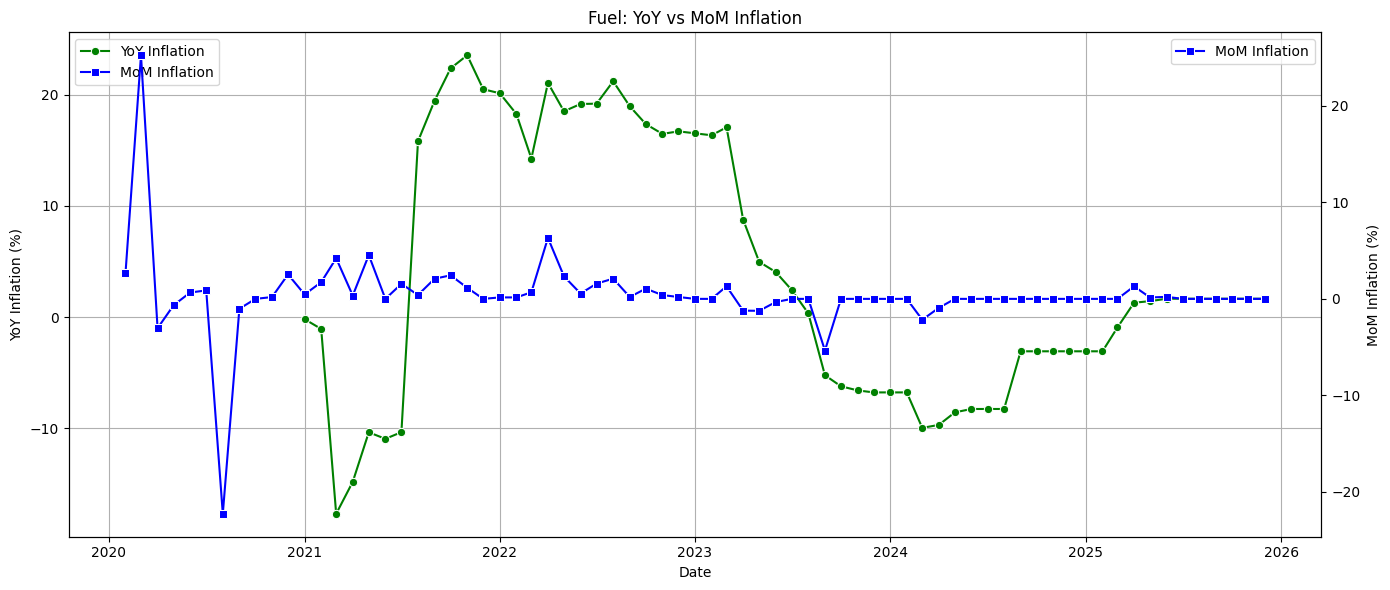

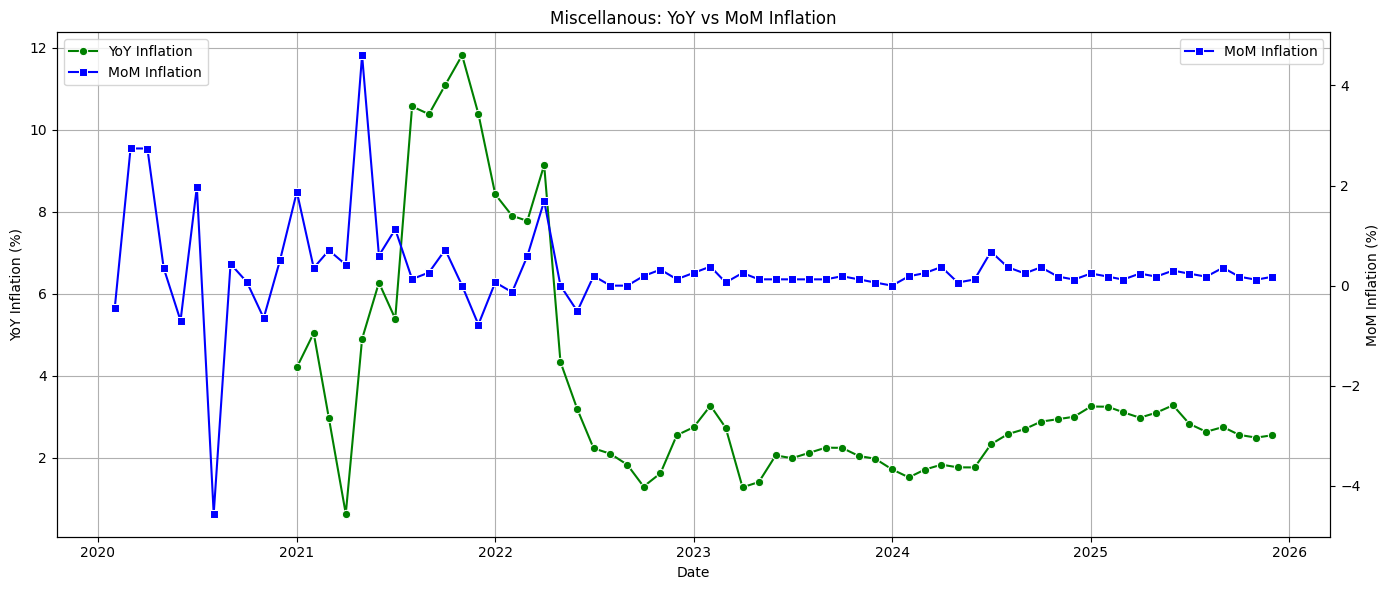

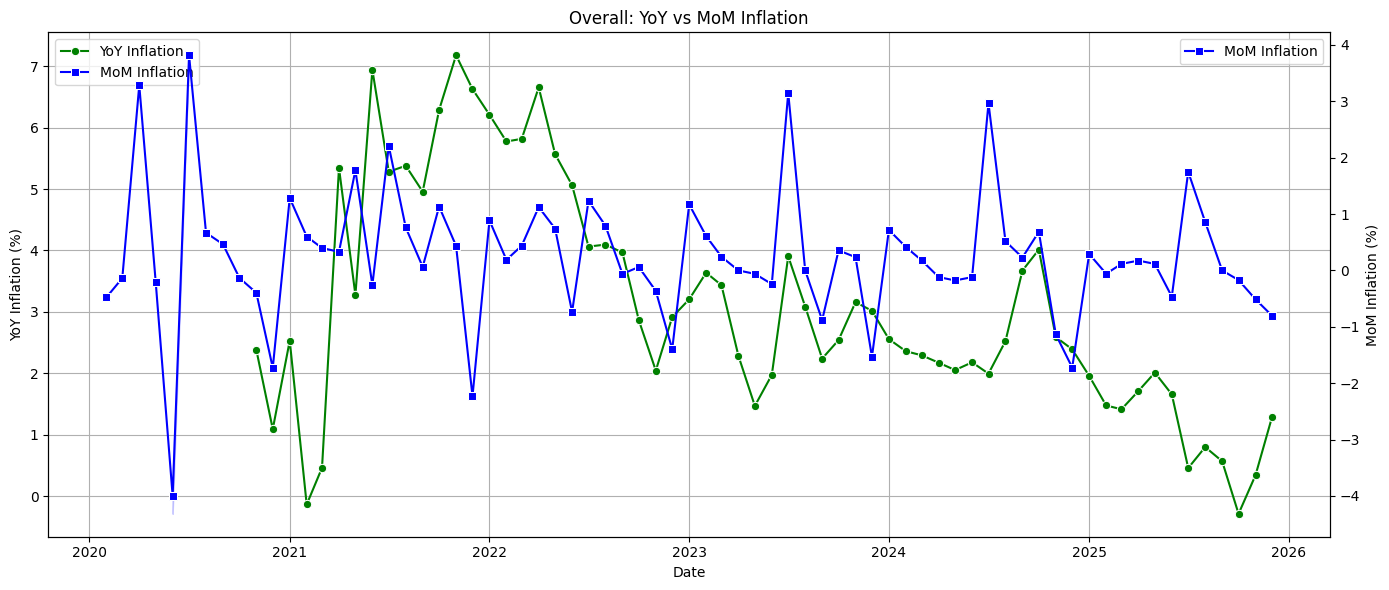

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unique categories
categories = urban_df['Category'].unique()

# Loop through each category
for category in categories:

    # Filter data
    temp_df = urban_df[urban_df['Category'] == category]

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # ---- YoY Inflation (Left Axis) ----
    sns.lineplot(
        data=temp_df,
        x='Date',
        y='Inflation_YoY',
        ax=ax1,
        marker='o',
        label='YoY Inflation',
        color= 'green'
    )

    ax1.set_ylabel('YoY Inflation (%)')
    ax1.set_xlabel('Date')
    ax1.tick_params(axis='y')

    # ---- Secondary Axis for MoM ----
    ax2 = ax1.twinx()

    sns.lineplot(
        data=temp_df,
        x='Date',
        y='Inflation_MoM',
        ax=ax2,
        marker='s',
        label='MoM Inflation',
        color='blue'
    )

    ax2.set_ylabel('MoM Inflation (%)')
    ax2.tick_params(axis='y')

    # ---- Title ----
    plt.title(f'{category}: YoY vs MoM Inflation')

    # ---- Improve readability ----
    ax1.grid(True)
    plt.xticks(rotation=45)

    # ---- Combined Legend ----
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()

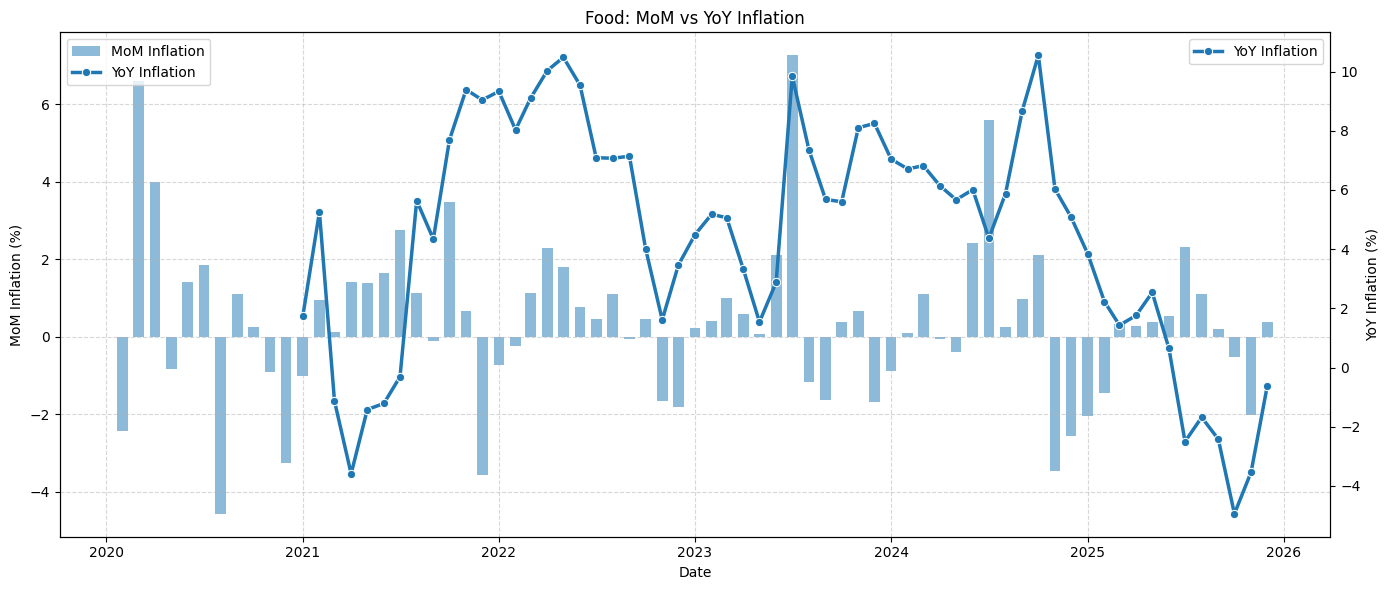

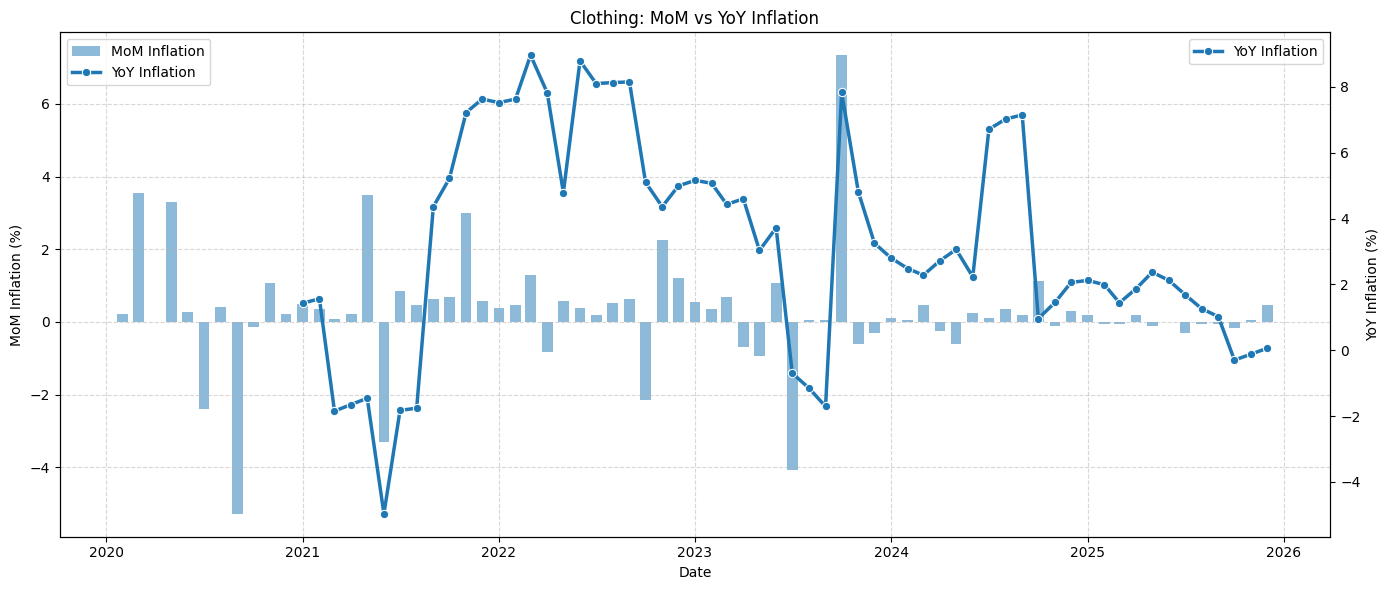

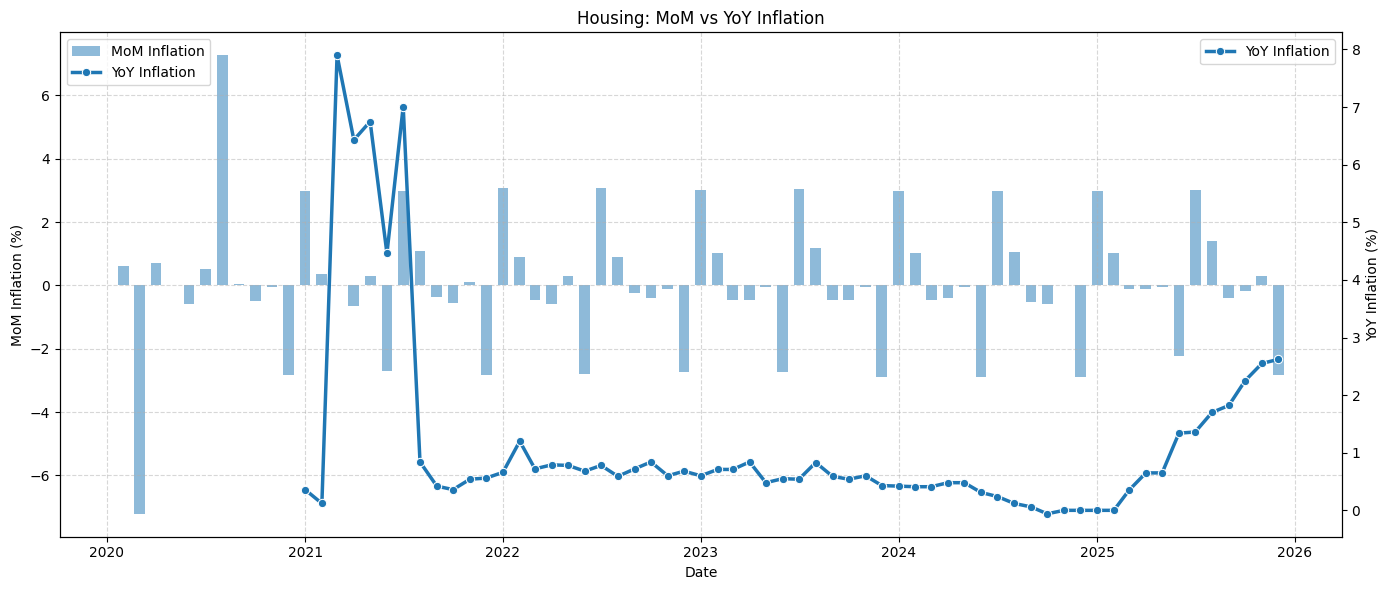

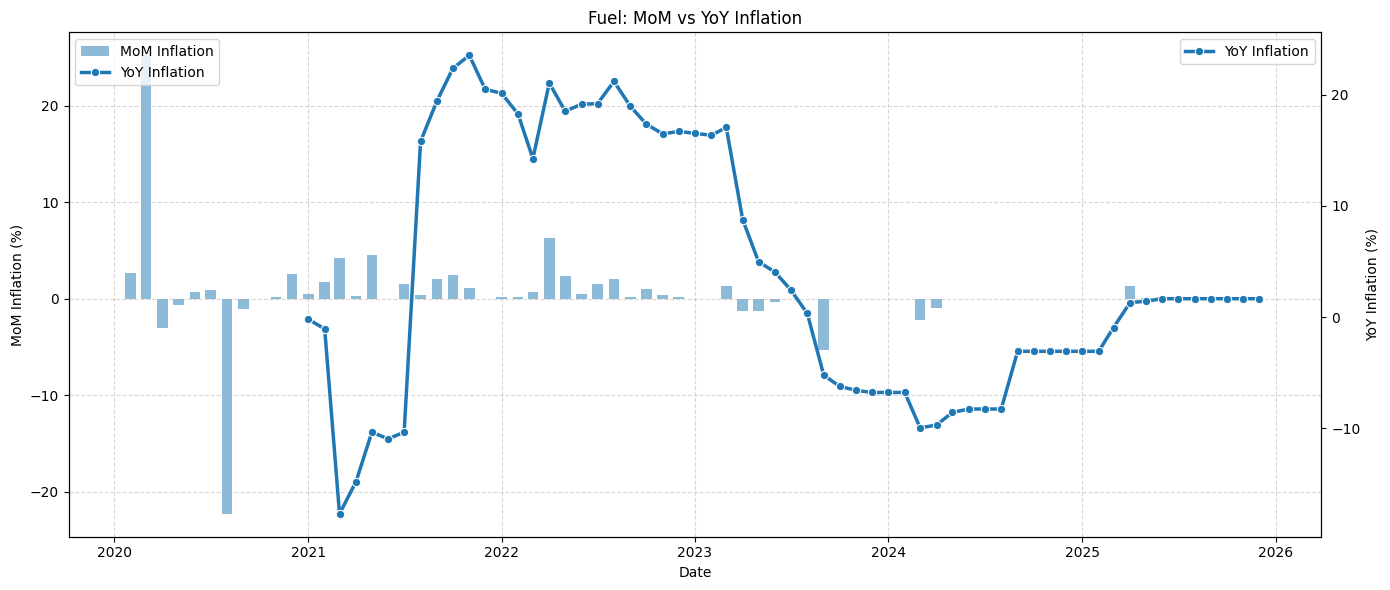

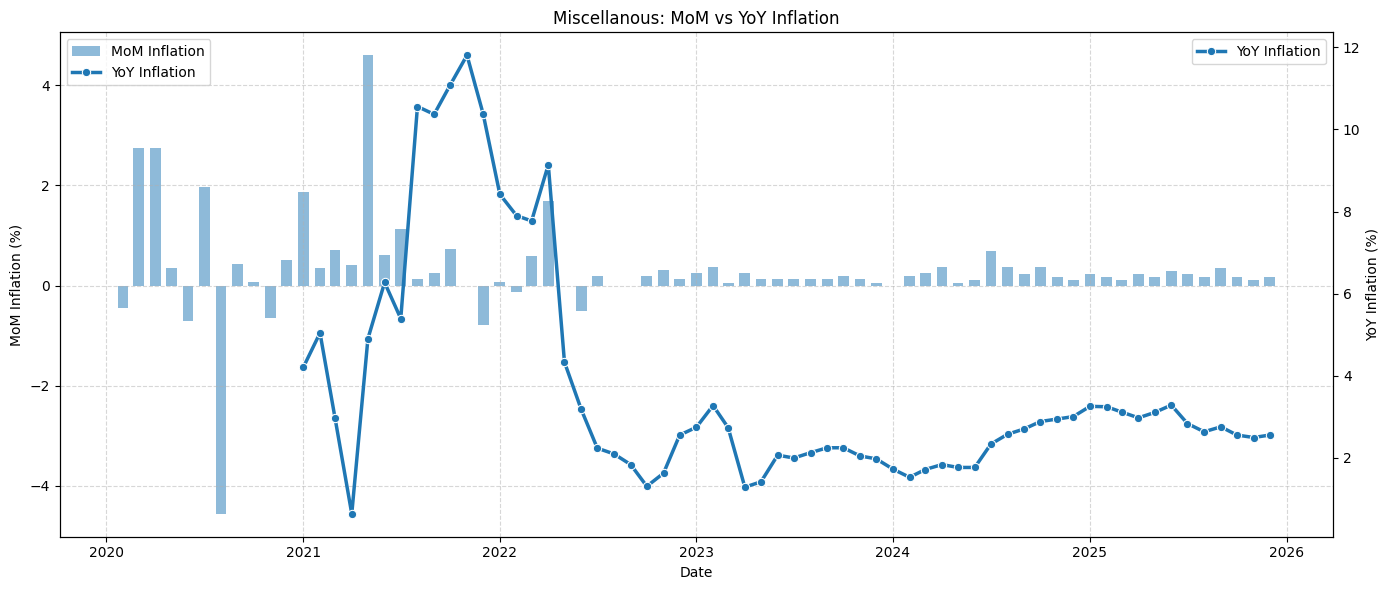

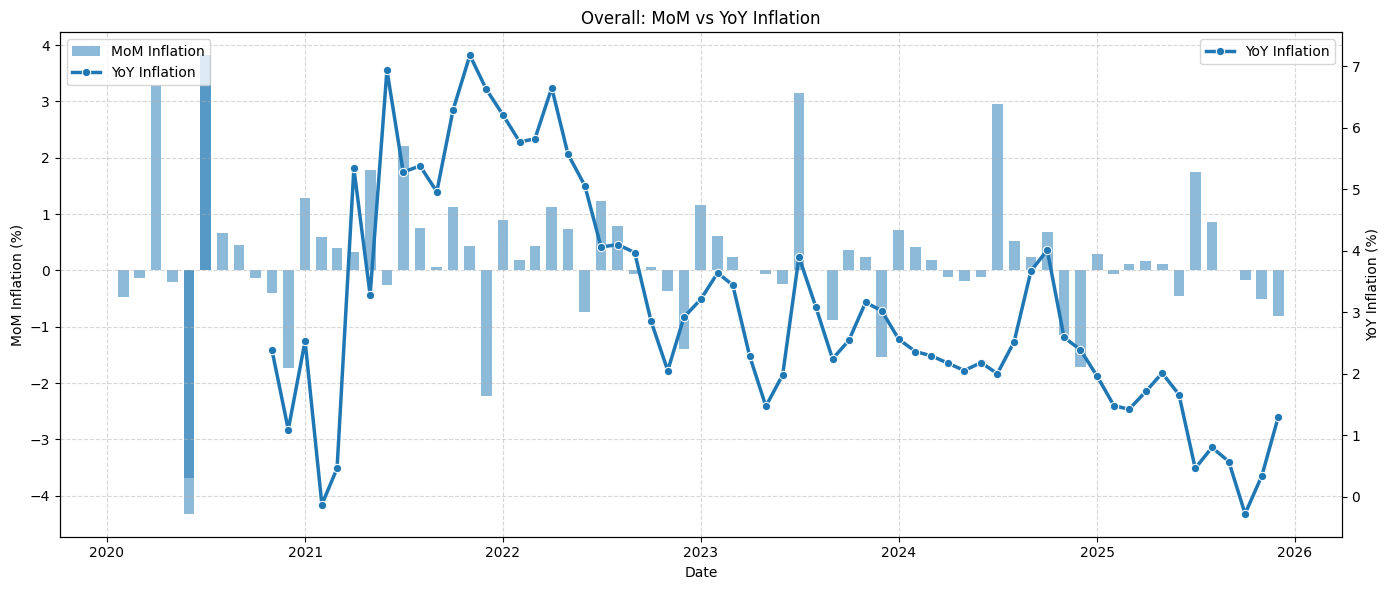

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create clean copy
urban_df = df[['Date', 'Category', 'Urban']].copy()

# Convert date column
urban_df['Date'] = pd.to_datetime(urban_df['Date'])

# -----------------------------
# Inflation Calculations
# -----------------------------

# Month-on-Month Inflation
urban_df['Inflation_MoM'] = (
    urban_df.groupby('Category')['Urban']
    .pct_change() * 100
)

# Year-on-Year Inflation
urban_df['Inflation_YoY'] = (
    urban_df.groupby('Category')['Urban']
    .pct_change(periods=12) * 100
)

# Round values
urban_df['Inflation_MoM'] = urban_df['Inflation_MoM'].round(2)
urban_df['Inflation_YoY'] = urban_df['Inflation_YoY'].round(2)

# -----------------------------
# Category-wise Graphs
# -----------------------------

categories = urban_df['Category'].unique()

for category in categories:

    # Filter category data
    temp_df = urban_df[
        urban_df['Category'] == category
    ]

    # Create figure
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # -----------------------------
    # BAR CHART → MoM Inflation
    # -----------------------------

    ax1.bar(
        temp_df['Date'],
        temp_df['Inflation_MoM'],
        width=20,
        alpha=0.5,
        label='MoM Inflation'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('MoM Inflation (%)')

    # -----------------------------
    # LINE CHART → YoY Inflation
    # -----------------------------

    ax2 = ax1.twinx()

    sns.lineplot(
        data=temp_df,
        x='Date',
        y='Inflation_YoY',
        marker='o',
        linewidth=2.5,
        ax=ax2,
        label='YoY Inflation'
    )

    ax2.set_ylabel('YoY Inflation (%)')

    # -----------------------------
    # TITLE & STYLING
    # -----------------------------

    plt.title(f'{category}: MoM vs YoY Inflation')

    ax1.grid(True, linestyle='--', alpha=0.5)

    plt.xticks(rotation=45)

    # -----------------------------
    # COMBINED LEGEND
    # -----------------------------

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()

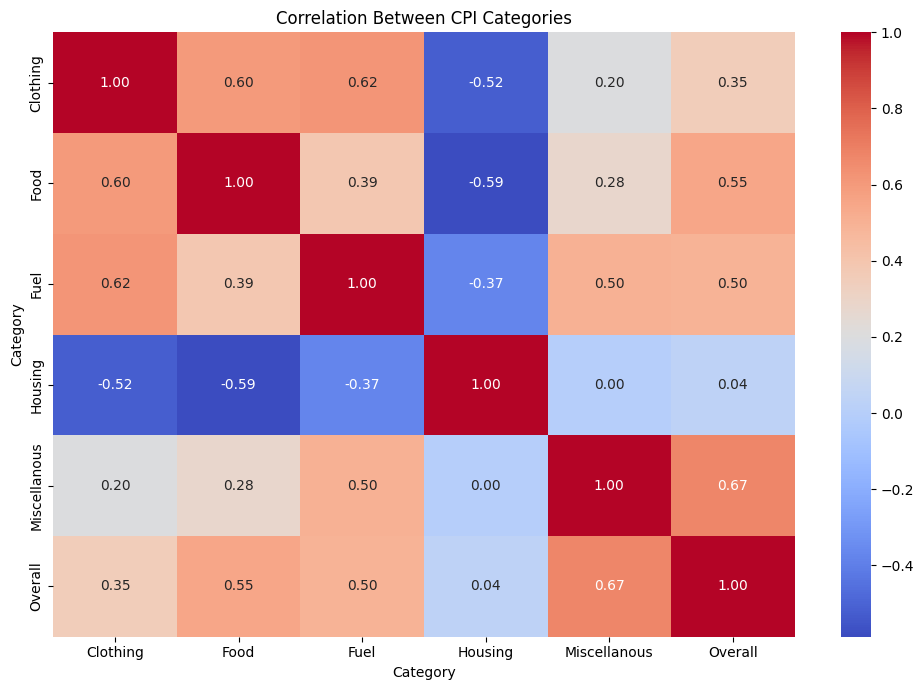

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create pivot table
pivot_df = urban_df.pivot_table(
    index='Date',
    columns='Category',
    values='Inflation_YoY'
)

# Correlation matrix
corr_matrix = pivot_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between CPI Categories')
plt.tight_layout()
plt.show()

#One category doesn't affect the other category

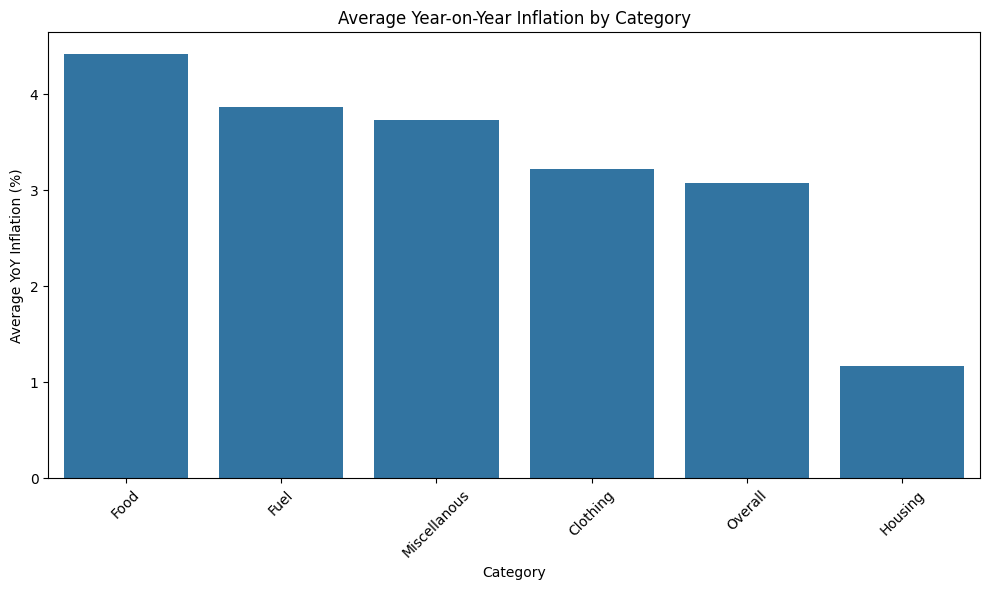

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average YoY inflation by category
avg_inflation = (
    urban_df.groupby('Category')['Inflation_YoY']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=avg_inflation,
    x='Category',
    y='Inflation_YoY'
)

plt.title('Average Year-on-Year Inflation by Category')
plt.xlabel('Category')
plt.ylabel('Average YoY Inflation (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#The average inflation chart shows that Food and Fuel experienced the highest inflationary pressure during 2020–2025, while Housing remained the most stable and least inflation-affected category.

In [ ]:
urban_df = df[['Date', 'Category', 'Urban']].copy()

urban_df['Date'] = pd.to_datetime(urban_df['Date'])


urban_df['MoM Inflation'] = (
    urban_df.groupby('Category')['Urban']
    .pct_change() * 100
)

# Year-on-Year Inflation
urban_df['YoY'] = (
    urban_df.groupby('Category')['Urban']
    .pct_change(periods=12) * 100
)

# Round values
urban_df['Inflation_MoM'] = urban_df['Inflation_MoM'].round(2)
urban_df['Inflation_YoY'] = urban_df['Inflation_YoY'].round(2)

# -----------------------------
# Category-wise Graphs
# -----------------------------

categories = urban_df['Category'].unique()

for category in categories:

    # Filter category data
    temp_df = urban_df[
        urban_df['Category'] == category
    ]

    # Create figure
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # -----------------------------
    # BAR CHART → MoM Inflation
    # -----------------------------

    ax1.bar(
        temp_df['Date'],
        temp_df['Inflation_MoM'],
        width=20,
        alpha=0.5,
        label='MoM Inflation'
    )

    ax1.set_xlabel('Date')
    ax1.set_ylabel('MoM Inflation (%)')

    # -----------------------------
    # LINE CHART → YoY Inflation
    # -----------------------------

    ax2 = ax1.twinx()

    sns.lineplot(
        data=temp_df,
        x='Date',
        y='Inflation_YoY',
        marker='o',
        linewidth=2.5,
        ax=ax2,
        label='YoY Inflation'
    )

    ax2.set_ylabel('YoY Inflation (%)')

    # -----------------------------
    # TITLE & STYLING
    # -----------------------------

    plt.title(f'{category}: MoM vs YoY Inflation')

    ax1.grid(True, linestyle='--', alpha=0.5)

    plt.xticks(rotation=45)

    # -----------------------------
    # COMBINED LEGEND
    # -----------------------------

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()